# 11 — Quick demo: 2 inner + 2 outer boroughs, one shared EPC model

**Question:** does the retrofit-priority approach work across London zones — dense inner
boroughs (flats, EPC-register data) and outer-East boroughs (houses, LAEP building-stock data)?

**Scope (run parameters in the next cell):** Tower Hamlets + Southwark (inner) and
Bexley + Havering (outer), a random sample of 10,000 homes per borough to keep the run fast.

> **In plain words — we are mixing two different data sources, and saying so openly:**
>
> | | inner (Tower Hamlets, Southwark) | outer (Bexley, Havering) |
> |---|---|---|
> | source | official EPC certificate register | GLA building-stock model (LAEP LBSM) |
> | EPC coverage | 100% — only certified homes appear at all | ~66% known, the rest predicted below |
> | caveat | homes without a certificate are invisible (selection bias) | modelled data, not measurements |
>
> The inner table lacks the LAEP area-context columns, so the model here can only use the facts
> **both** sources share: property type, built form, age band, tenure, borough. Fewer clues →
> expect a weaker model than notebook 10. The point of this notebook is the **cross-zone
> comparison**, not the best score.

In [1]:
# --- shared setup cell ---
%load_ext autoreload
%autoreload 2
import sys, pathlib
_p = pathlib.Path.cwd()
ROOT = next(a for a in (_p, *_p.parents) if (a / "src").is_dir() and (a / "configs").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import get_config, configure_logging
from src.logging_utils import get_logger, log_duration

MODE = "debug"                            # debug scale: 2 CV folds — this is a quick demo run
INNER = ["Tower Hamlets", "Southwark"]    # from data/processed/domestic_inner_ready.parquet
OUTER = ["Bexley", "Havering"]            # from data/processed/domestic_model.parquet
SAMPLE_PER_BOROUGH = 10_000               # run parameter: keeps this notebook laptop-quick
cfg = get_config(MODE)
configure_logging(cfg)
log = get_logger("notebook.buildings.11_mixed")

import polars as pl
import matplotlib.pyplot as plt
from src.viz import CAT, TENURE_COLORS, NEUTRAL, apply_style, bar_labels
apply_style()

from src.features import TARGET_COL, priority_score
from src.models import make_model_set, make_model
from src.evaluation import build_report, persist_report

# features BOTH sources share (LAEP LSOA context + floor area don't exist for inner London)
MIXED_FEATURES = ["property_type", "built_form", "construction_age_band", "tenure", "borough"]
COMMON = MIXED_FEATURES + ["uprn", "heat_demand_kwh", "is_social", TARGET_COL, "epc_rating",
                           "epc_score_known", "lsoa21cd", "lsoa21nm", "easting", "northing"]

def harmonize(frame: pl.DataFrame, zone: str, source: str) -> pl.DataFrame:
    """Align dtypes across the two tables and tag provenance."""
    return frame.select(COMMON).with_columns(
        pl.col(TARGET_COL).cast(pl.Float64),
        pl.col("easting").cast(pl.Float64),
        pl.col("northing").cast(pl.Float64),
        pl.lit(zone).alias("london_zone"),
        pl.lit(source).alias("data_source"),
    )

inner = harmonize(
    pl.read_parquet(cfg.data_raw.parent / "processed" / "domestic_inner_ready.parquet")
      .filter(pl.col("borough").is_in(INNER)), "inner", "epc_register")
outer = harmonize(
    pl.read_parquet(cfg.data_raw.parent / "processed" / "domestic_model.parquet")
      .filter(pl.col("borough").is_in(OUTER)), "outer", "laep_lbsm")

parts = []
for frame in (inner, outer):
    for b in sorted(frame["borough"].unique().to_list()):
        sub = frame.filter(pl.col(b_col := "borough") == b)
        parts.append(sub.sample(n=min(SAMPLE_PER_BOROUGH, sub.height), seed=cfg.seed))
dom = pl.concat(parts)

# GroupKFold groups can't be null — a small number of register rows lack an LSOA code
n0 = dom.height
dom = dom.filter(pl.col("lsoa21cd").is_not_null())
if n0 - dom.height:
    log.info("dropped %d rows with null lsoa21cd (no neighbourhood group for CV)", n0 - dom.height)

known = dom.filter(pl.col("epc_score_known") & pl.col(TARGET_COL).is_not_null())
unknown = dom.filter(~pl.col("epc_score_known") | pl.col(TARGET_COL).is_null())
log.info("mixed scope: %s | properties=%d | EPC known=%d (%.1f%%) | unknown=%d (zones: %s)",
         sorted(dom["borough"].unique().to_list()), dom.height, known.height,
         100 * known.height / dom.height, unknown.height,
         sorted(unknown["london_zone"].unique().to_list()))

2026-07-06 12:07:06 | INFO     | src.notebook.buildings.11_mixed | dropped 38 rows with null lsoa21cd (no neighbourhood group for CV)


2026-07-06 12:07:06 | INFO     | src.notebook.buildings.11_mixed | mixed scope: ['Bexley', 'Havering', 'Southwark', 'Tower Hamlets'] | properties=39962 | EPC known=32783 (82.0%) | unknown=7179 (zones: ['outer'])


## 1 · Evaluate — same exam as notebook 10

Five model families (dummy baseline first), folds never split a neighbourhood (GroupKFold on
LSOA). See `10_priority_score.ipynb` for the plain-words reading guide of every output — this
notebook only adds the inner/outer angle.

In [2]:
X = known.select(MIXED_FEATURES).to_pandas()
y = known[TARGET_COL].to_pandas()
groups = known["lsoa21cd"].to_list()

models = make_model_set(cfg.models, seed=cfg.seed)
report = build_report(models, X, y, groups=groups, n_splits=cfg.cv_folds)
report.cache_predictions()
report

2026-07-06 12:07:06 | INFO     | src.models | model set: ['dummy', 'glm', 'hgbt', 'rf', 'ridge'] (seed=42)


2026-07-06 12:07:06 | INFO     | src.evaluation.vouch | build_report: models=['dummy', 'glm', 'hgbt', 'rf', 'ridge'] | X=(32783, 5) | groups=643 LSOAs | GroupKFold(2) [spatial leakage guard]


2026-07-06 12:07:06 | INFO     | src.evaluation.vouch | ▶ skore.evaluate ['dummy', 'glm', 'hgbt', 'rf', 'ridge'] …


2026-07-06 12:07:26 | INFO     | src.evaluation.vouch | ✔ skore.evaluate ['dummy', 'glm', 'hgbt', 'rf', 'ridge'] done in 19.591s


2026-07-06 12:07:26 | INFO     | src.evaluation.vouch | build_report done: ComparisonReport


ComparisonReport:
        ['dummy', 'glm', 'hgbt', 'rf', 'ridge']

                              dummy       glm      hgbt        rf     ridge  \
                       mean      mean      mean      mean      mean   
Metric                                                                
Score_1           -0.000082       NaN       NaN       NaN       NaN   
R²                -0.000082  0.532450  0.558778  0.546812  0.545965   
RMSE              11.894700  8.133016  7.900673  8.007115  8.014509   
MAE                9.398183  5.821143  5.533957  5.645246  5.674851   
MAPE               0.189932  0.130648  0.125088  0.126657  0.127810   
Fit time (s)       0.003407  5.402413  1.087469  1.247524  0.709772   
Predict time (s)   0.000052  0.298168  0.442110  0.220903  0.292239   
Score_2                 NaN  0.456891  0.558778  0.546812  0.545965   

                         dummy       glm      hgbt            rf     ridge  
                           std       std       std           std       std  
Metric                                                                      
Score_1           6.984189e-07       NaN       NaN           NaN       NaN  
R²                6.984189e-07  0.003060  0.007693  6.415553e-03  0.010300  
RMSE              5.048640e-02  0.061138  0.102416  9.066490e-02  0.124926  
MAE               7.334940e-02  0.080655  0.008886  9.912585e-03  0.014512  
MAPE              8.498611e-03  0.006456  0.007564  7.699890e-03  0.007835  
Fit time (s)      4.160507e-03  0.105627  0.035022  8.827581e-02  0.018239  
Predict time (s)  1.067027e-06  0.014623  0.036394  4.030498e-07  0.006856  
Score_2                    NaN  0.007614  0.007693  6.415553e-03  0.010300  
        Call `report.to_markdown()` for a markdown summary of the report's contents.

## 2 · VOUCH — checks, then metrics vs baseline

> **In plain words:** first the automatic health check-up (can this result be trusted?), then
> the scores. RMSE = typical miss in EPC points, lower is better; the dummy column is the
> "no intelligence" reference every model must beat.

In [3]:
report.checks.summarize()

Checks summary: 4 issue(s), 4 tip(s), 3 passed, 5 not applicable, 0 ignored.
Issues:
- [SKD010] Model slower than baseline. Detected in: [glm]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd010-slower-than-baseline.
- [SKD002] Potential underfitting. Detected in: [dummy]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd002-underfitting.
- [SKD009] Model worse than baseline. Detected in: [dummy], [glm], [hgbt], [rf], [ridge]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd009-worse-than-baseline.
- [SKD008] Highly correlated input features. Detected in: [glm], [hgbt], [rf], [ridge]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd008-correlated-features.
Tips:
- [SKD012] Useless features. Detected in: [dummy]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd012-useless-features.
- [SKD011] Golden feature. Detected in: [dummy], [hgbt]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd011-golden-feature.
- [SKD006] Coefficient interpretation. Detected in: [glm], [ridge]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd006-unscaled-coefficients.
- [SKD016] Estimator not tuned. Detected in: [hgbt], [ridge]. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd016-estimator-not-tuned.
Passed:
- [SKD003] Inconsistent performance across splits
- [SKD001] Potential overfitting
- [SKD007] MDI biased for high-cardinality features
Not Applicable:
- [SKD014] Hyperparameters at search edge. Estimator is not a BaseSearchCV instance. Got <class 'sklearn.dummy.DummyRegressor'>. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd014-hyperparams-at-search-edge.
- [SKD005] Underrepresented classes. ML task is not multiclass classification. Got regression. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd005-underrepresented-classes.
- [SKD013] Train-test overlap in time series. No datetime column found. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd013-train-test-time-overlap.
- [SKD015] Hyperparameters worth tuning. Estimator is not a BaseSearchCV instance. Got <class 'sklearn.dummy.DummyRegressor'>. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd015-hyperparameters-worth-tuning.
- [SKD004] High class imbalance. ML task is not binary classification. Got regression. Read more about this here: https://docs.skore.probabl.ai/0.22/user_guide/automated_checks.html#skd004-high-class-imbalance.
Mute a check with .checks.summarize(ignore=['<code>']).

mean                                          \
Estimator             dummy       glm      hgbt        rf     ridge   
Metric                                                                
Score_1           -0.000082       NaN       NaN       NaN       NaN   
R²                -0.000082  0.532450  0.558778  0.546812  0.545965   
RMSE              11.894700  8.133016  7.900673  8.007115  8.014509   
MAE                9.398183  5.821143  5.533957  5.645246  5.674851   
MAPE               0.189932  0.130648  0.125088  0.126657  0.127810   
Fit time (s)       0.003407  5.402413  1.087469  1.247524  0.709772   
Predict time (s)   0.000052  0.298168  0.442110  0.220903  0.292239   
Score_2                 NaN  0.456891  0.558778  0.546812  0.545965   

                           std                                              
Estimator                dummy       glm      hgbt            rf     ridge  
Metric                                                                      
Score_1           6.984189e-07       NaN       NaN           NaN       NaN  
R²                6.984189e-07  0.003060  0.007693  6.415553e-03  0.010300  
RMSE              5.048640e-02  0.061138  0.102416  9.066490e-02  0.124926  
MAE               7.334940e-02  0.080655  0.008886  9.912585e-03  0.014512  
MAPE              8.498611e-03  0.006456  0.007564  7.699890e-03  0.007835  
Fit time (s)      4.160507e-03  0.105627  0.035022  8.827581e-02  0.018239  
Predict time (s)  1.067027e-06  0.014623  0.036394  4.030498e-07  0.006856  
Score_2                    NaN  0.007614  0.007693  6.415553e-03  0.010300  
Use .frame() to control the format of the output.

2026-07-06 12:13:25 | INFO     | src.notebook.buildings.11_mixed | metrics (GroupKFold 2): RMSE {'dummy': 11.89, 'glm': 8.13, 'hgbt': 7.9, 'rf': 8.01, 'ridge': 8.01} | best=hgbt (7.90 vs dummy 11.89 → −34%)


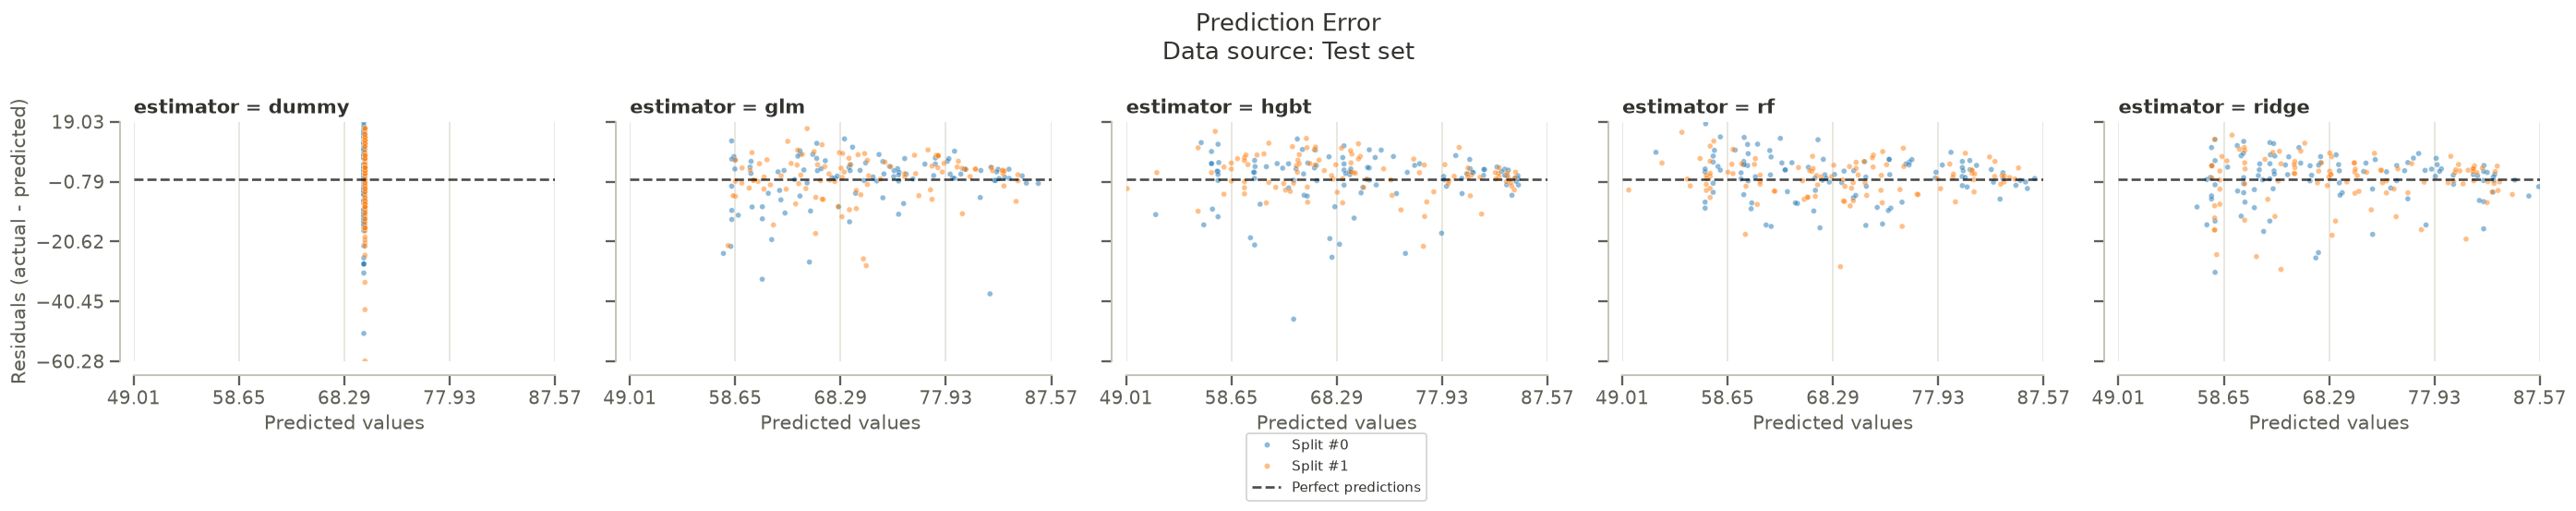

In [4]:
summary = report.metrics.summarize()
display(summary)

frame = summary.frame()
rmse = frame.loc["RMSE", "mean"]
best_name = rmse.idxmin()
log.info("metrics (GroupKFold %d): RMSE %s | best=%s (%.2f vs dummy %.2f → −%.0f%%)",
         cfg.cv_folds, rmse.round(2).to_dict(), best_name, rmse[best_name], rmse["dummy"],
         100 * (1 - rmse[best_name] / rmse["dummy"]))
report.metrics.prediction_error().plot()

In [5]:
with log_duration(log, "permutation importance"):
    report.inspection.permutation_importance(seed=cfg.seed).plot()

2026-07-06 12:13:26 | INFO     | src.notebook.buildings.11_mixed | ▶ permutation importance …


2026-07-06 12:14:35 | INFO     | src.notebook.buildings.11_mixed | ✔ permutation importance done in 67.929s


In [6]:
persist_report(report, "epc_model_mixed_2inner2outer", cfg.outputs / "skore_project")

2026-07-06 12:14:36 | INFO     | src.evaluation.vouch | persisted 5 sub-reports for 'epc_model_mixed_2inner2outer' in /home/dhuencho/dev_py/0001_start_pytorch/src/0011_hackaton_gov/outputs/skore_project/retrofit


## 3 · Score all sampled homes (inner + outer together)

> **In plain words:** the winning model fills in the missing EPCs (those exist only on the
> outer side — the inner register has certificates for every included home), then every home
> gets the 0–100 priority score. ⚠ Percentiles are computed **within this mixed sample**, so
> inner and outer homes compete in one league: outer houses tend to have higher heat demand
> than inner flats, which pushes outer homes up the ranking — visible in the zone table below.

In [7]:
best = make_model(best_name, seed=cfg.seed)
with log_duration(log, f"fit {best_name} on all known rows"):
    best.fit(X, y)
pred = best.predict(unknown.select(MIXED_FEATURES).to_pandas())

scored_input = pl.concat([
    known.with_columns(pl.col(TARGET_COL).alias("epc_score_final"),
                       pl.lit("known").alias("epc_source")),
    unknown.with_columns(pl.Series("epc_score_final", pred, dtype=pl.Float64),
                         pl.lit(f"predicted_{best_name}").alias("epc_source")),
])
scored = priority_score(scored_input)

out_path = cfg.data_raw.parent / "processed" / "retrofit_priority_mixed.parquet"
scored.write_parquet(out_path)
log.info("saved %s (%d×%d)", out_path, scored.height, scored.width)

2026-07-06 12:14:36 | INFO     | src.notebook.buildings.11_mixed | ▶ fit hgbt on all known rows …


2026-07-06 12:14:38 | INFO     | src.notebook.buildings.11_mixed | ✔ fit hgbt on all known rows done in 1.558s


2026-07-06 12:14:38 | INFO     | src.features.retrofit | priority_score: 39962 properties | weights epc/heat/social=0.40/0.40/0.20 | high_priority=7993 (top 20%, threshold=64.6) | social share of top=21.9%


2026-07-06 12:14:38 | INFO     | src.notebook.buildings.11_mixed | saved /home/dhuencho/dev_py/0001_start_pytorch/src/0011_hackaton_gov/data/processed/retrofit_priority_mixed.parquet (39962×23)


london_zone,n_all,n_top,flag_rate
str,u32,u32,f64
"""inner""",19962,2339,0.117173
"""outer""",20000,5654,0.2827


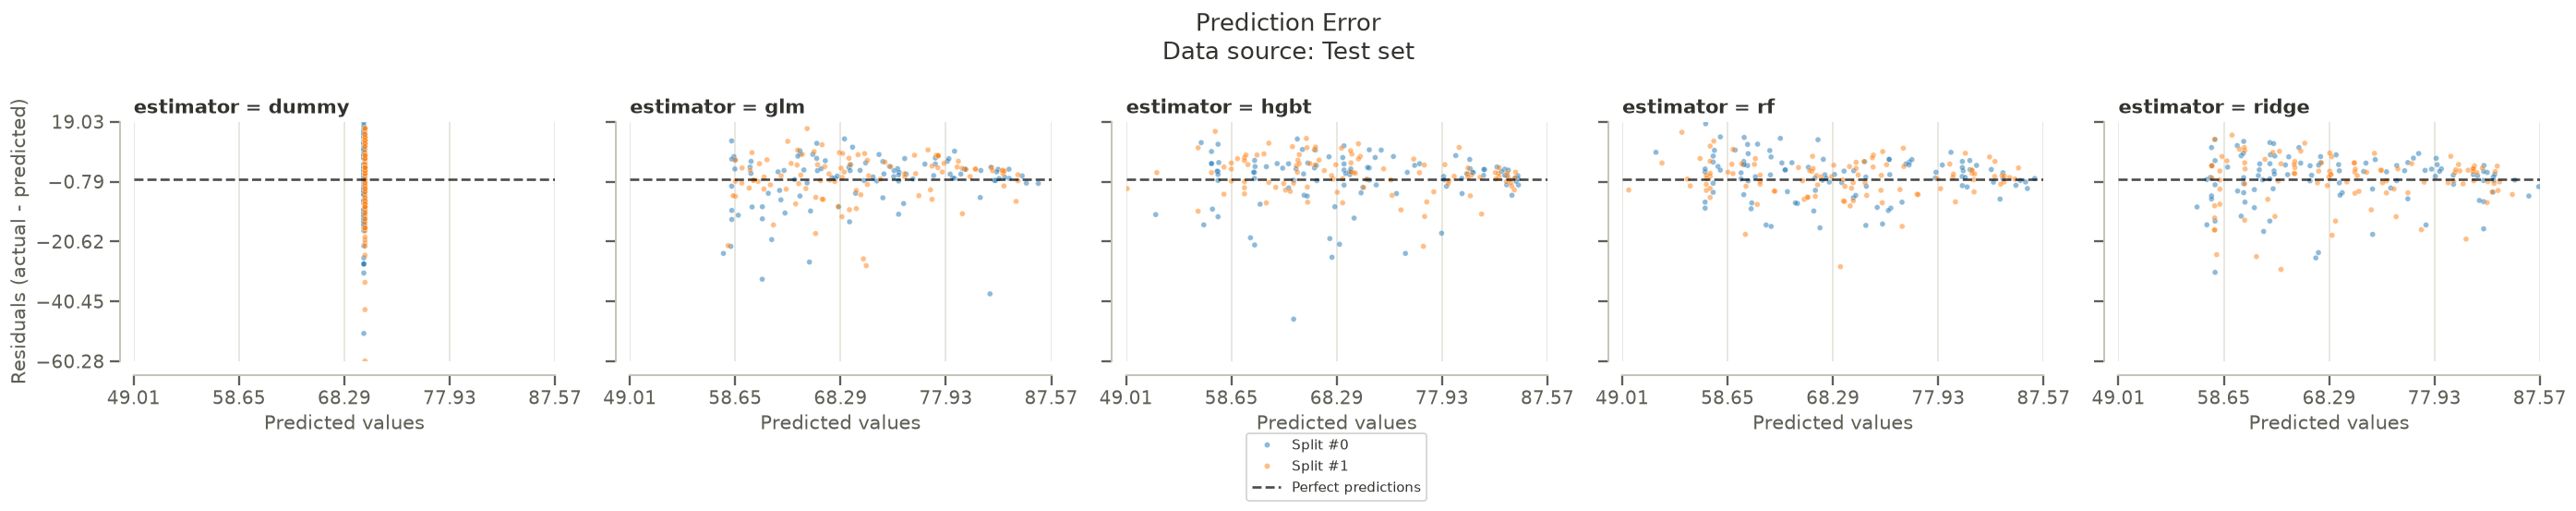

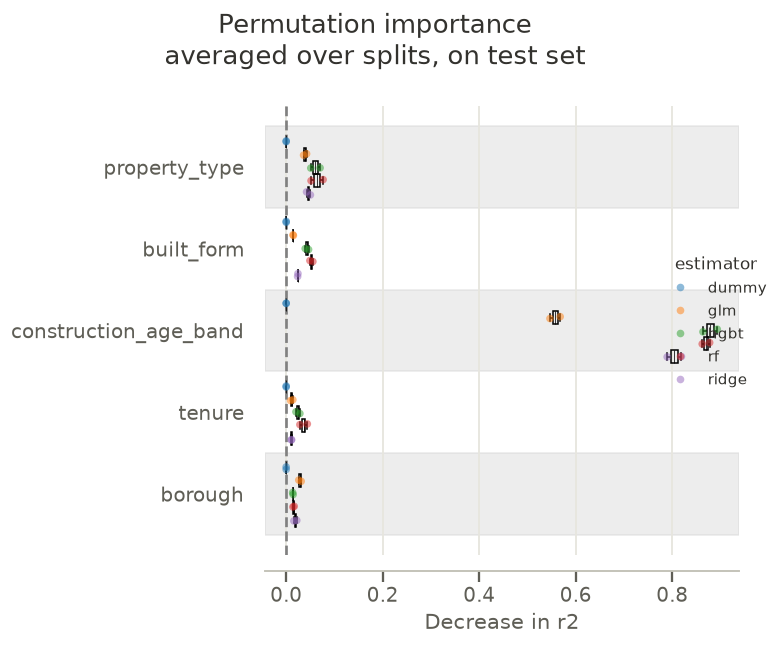

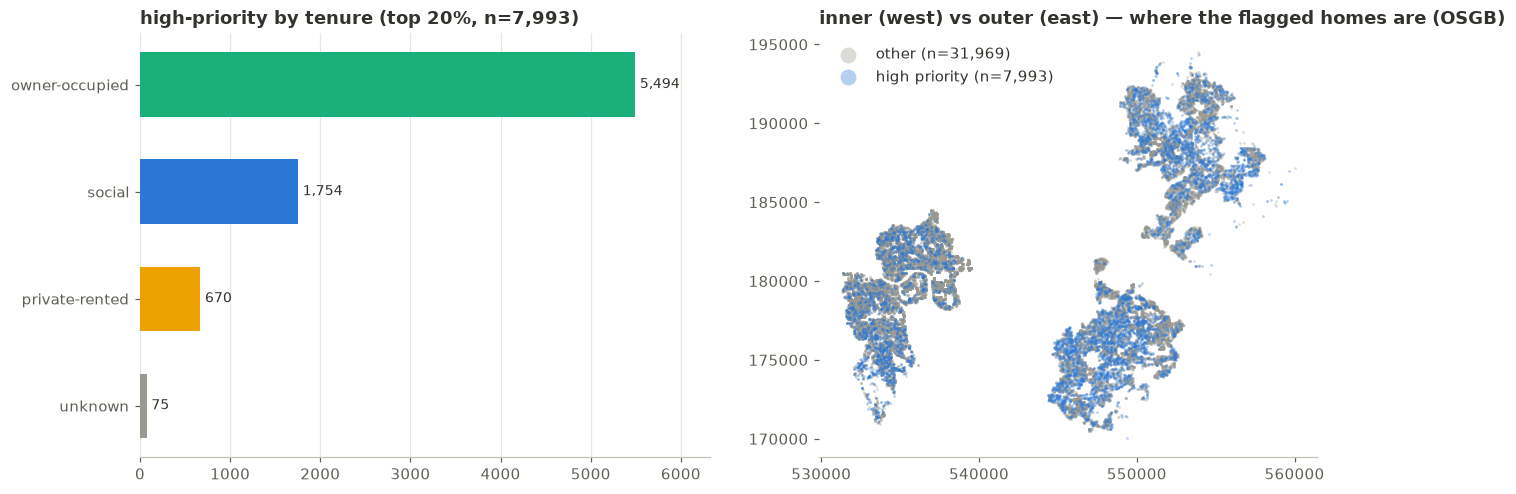

In [8]:
top = scored.filter(pl.col("high_priority"))
zone_profile = (scored.group_by("london_zone")
                .agg(pl.len().alias("n_all"), pl.col("high_priority").sum().alias("n_top"))
                .with_columns((pl.col("n_top") / pl.col("n_all")).alias("flag_rate"))
                .sort("london_zone"))
display(zone_profile)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
profile = top.group_by("tenure").agg(pl.len().alias("n")).sort("n", descending=True)
tenures = profile["tenure"].to_list()
axes[0].barh(tenures[::-1], profile["n"].to_list()[::-1],
             color=[TENURE_COLORS.get(t, NEUTRAL) for t in tenures[::-1]], height=0.6)
bar_labels(axes[0])
axes[0].set_title(f"high-priority by tenure (top 20%, n={top.height:,})")
axes[0].margins(x=0.15)

rest = scored.filter(~pl.col("high_priority"))
axes[1].scatter(rest["easting"], rest["northing"], s=3, color=NEUTRAL, alpha=0.35,
                label=f"other (n={rest.height:,})", linewidths=0)
axes[1].scatter(top["easting"], top["northing"], s=3, color=CAT[0], alpha=0.35,
                label=f"high priority (n={top.height:,})", linewidths=0)
axes[1].set_title("inner (west) vs outer (east) — where the flagged homes are (OSGB)")
axes[1].set_aspect("equal")
axes[1].locator_params(axis="x", nbins=4)
axes[1].legend(markerscale=6, frameon=False, loc="upper left")
axes[1].grid(False)
fig.tight_layout()

In [9]:
social_top = top["is_social"].mean()
social_base = scored["is_social"].mean()
predicted_share = (top["epc_source"] != "known").mean()
by_zone = {r["london_zone"]: r["flag_rate"] for r in zone_profile.iter_rows(named=True)}
headline = (
    f"{top.height:,} of {scored.height:,} sampled homes flagged (top 20%) across 2 inner + 2 outer boroughs. "
    f"Flag rate by zone: inner {by_zone.get('inner', 0):.1%} vs outer {by_zone.get('outer', 0):.1%}. "
    f"Social housing: {social_top:.1%} of flagged vs {social_base:.1%} of stock. "
    f"{predicted_share:.1%} of flagged rely on a predicted EPC ({best_name}: RMSE {rmse[best_name]:.2f} "
    f"vs dummy {rmse['dummy']:.2f}, GroupKFold on LSOA)."
)
print(headline)
log.info("HEADLINE | %s", headline)

2026-07-06 12:14:39 | INFO     | src.notebook.buildings.11_mixed | HEADLINE | 7,993 of 39,962 sampled homes flagged (top 20%) across 2 inner + 2 outer boroughs. Flag rate by zone: inner 11.7% vs outer 28.3%. Social housing: 21.9% of flagged vs 15.9% of stock. 38.0% of flagged rely on a predicted EPC (hgbt: RMSE 7.90 vs dummy 11.89, GroupKFold on LSOA).


7,993 of 39,962 sampled homes flagged (top 20%) across 2 inner + 2 outer boroughs. Flag rate by zone: inner 11.7% vs outer 28.3%. Social housing: 21.9% of flagged vs 15.9% of stock. 38.0% of flagged rely on a predicted EPC (hgbt: RMSE 7.90 vs dummy 11.89, GroupKFold on LSOA).


> **In plain words — what to take from this notebook (and what not to):**
> - The same pipeline, model set and honesty checks **run unchanged on inner-London data** —
>   the approach is not tied to the East-London dataset.
> - The inner source only contains homes that *have* a certificate, so it cannot tell us about
>   inner homes without one — the group the model exists for. A production inner-London version
>   would need the full building stock, not just the register.
> - Scores compare homes **within this mixed sample** of 4 boroughs; do not read them as
>   London-wide rankings. This is a feasibility demo, deliberately quick.